# 기후 변화와 산불과의 상관관계
- 기후 데이터는 기상자료개방포털, 산불 데이터는 KOSIS 국가통계 이용

In [1]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import numpy as np
import csv
import re
plt.rc('font',family = 'Malgun Gothic')

In [2]:
# 데이터 불러오기
df_fire = pd.read_excel('data/월별_발생건수_20260203152351.xlsx')# 월별로 나누어진 데이터
df_temp = pd.read_excel('data/기온.xlsx')
df_rain = pd.read_excel('data/강수량.xlsx')
df_hum = pd.read_excel('data/습도.xlsx')
df_wind = pd.read_excel('data/풍속.xlsx')
df_fire_ex = pd.read_excel('data/산불발생_현황_총괄.xlsx') # 산불 피해 금액이 포함된 데이터
# 데이터 결측값
display(df_fire.isna().sum())
display(df_temp.isna().sum())
display(df_rain.isna().sum())
display(df_hum.isna().sum())
display(df_wind.isna().sum())
display(df_fire_ex.isna().sum())
# df_fire의 월별은 multiindex구조이기 때문에

c:\anaconda3\envs\bigdata\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


월별      13
기간별      0
1997     0
1998     0
1999     0
2000     0
2001     0
2002     0
2003     0
2004     0
2005     0
2006     0
2007     0
2008     0
2009     0
2010     0
2011     0
2012     0
2013     0
2014     0
2015     0
2016     0
2017     0
2018     0
2019     0
2020     0
2021     0
2022     0
2023     0
2024     0
dtype: int64

지역번호         0
지역명          0
일시           0
평균기온(℃)      0
평균최고기온(℃)    0
최고기온(℃)      0
최고기온관측지점     0
평균최저기온(℃)    0
최저기온(℃)      0
최저기온관측지점     0
dtype: int64

지역번호            0
지역명             0
일시              0
평균월강수량(mm)      0
최다월강수량(mm)      0
최다강수량지점         0
1시간최다강수량(mm)    0
1시간최다강수량지점      0
dtype: int64

지역번호         0
지역명          0
일시           0
평균습도(%rh)    0
최저습도(%rh)    0
최저습도지점       0
dtype: int64

지역번호           0
지역명            0
일시             0
평균풍속(m/s)      0
최대풍속(m/s)      0
최대풍속지점         0
최대순간풍속(m/s)    0
최대순간풍속지점       0
dtype: int64

기간별(1)    0
1997      0
1997.1    0
1997.2    0
1997.3    0
         ..
2024      0
2024.1    0
2024.2    0
2024.3    0
2024.4    0
Length: 141, dtype: int64

### 총괄 산불 데이터를 바탕으로 연도별 산불 피해 건수, 피해액 시각화

In [3]:
# 총괄 산불 데이터 전처리
# 필요없는 행,열 날리기
df_fire_ex.drop(index=1,axis=0,inplace=True)
df_fire_ex.drop(['기간별(1)'],axis=1,inplace=True)

# 컬럼명 뒤의 .1, .2, .3... 등을 제거
df_fire_ex.columns = [re.sub(r'\.\d+$', '', col) for col in df_fire_ex.columns]

df_fire_ex.reset_index(drop=True,inplace=True)
df_fire_ex



,1997,1997,1997,1997,1997,1998,1998,1998,1998,1998,...,2023,2023,2023,2023,2023,2024,2024,2024,2024,2024
0,건수 (건),면적 (ha),건당 피해면적 (ha),피해재적 (㎥),피해금액 (백만원),건수 (건),면적 (ha),건당 피해면적 (ha),피해재적 (㎥),피해금액 (백만원),...,건수 (건),면적 (ha),건당 피해면적 (ha),피해재적 (㎥),피해금액 (백만원),건수 (건),면적 (ha),건당 피해면적 (ha),피해재적 (㎥),피해금액 (백만원)
1,524,2330,4.4,40815,1629,265,1014,3.8,44092,2516,...,596,4992,8.4,464130,285429,279,132,0.5,5629,9244


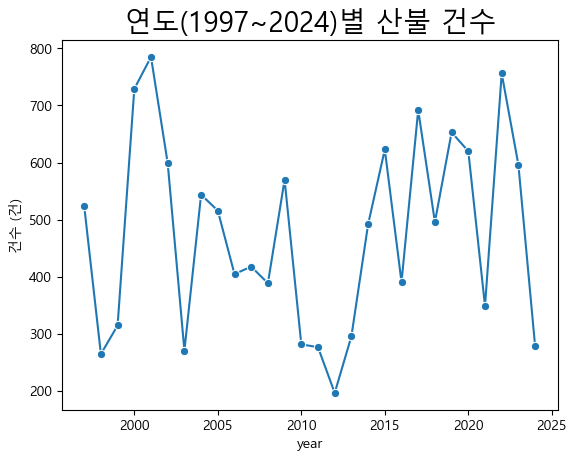

In [4]:
# 데이터 프레임을 연도는 앞쪽으로 오고, ['건수 (건)','면적 (ha)','건당 피해면적 (ha)','피해재적 (㎥)','피해금액 (백만원)']를 column으로 가지는 데이터프레임 생성
df= pd.DataFrame(columns=['건수 (건)','면적 (ha)','건당 피해면적 (ha)','피해재적 (㎥)','피해금액 (백만원)']) 
#for문을 사용해서 df행 추가로 생성
for i in range(0,28):
    df.loc[i+1997] = df_fire_ex.iloc[1,5*i:5*i+5].tolist()
# reset_index()하고 index를 year로 바꿈
df = df.reset_index().rename(columns={'index':'year'})
df = df.astype(int)

# 연도별 산불 건수
sns.lineplot(data=df,x='year',y='건수 (건)',marker='o')
plt.title('연도(1997~2024)별 산불 건수',size=20)
plt.show()

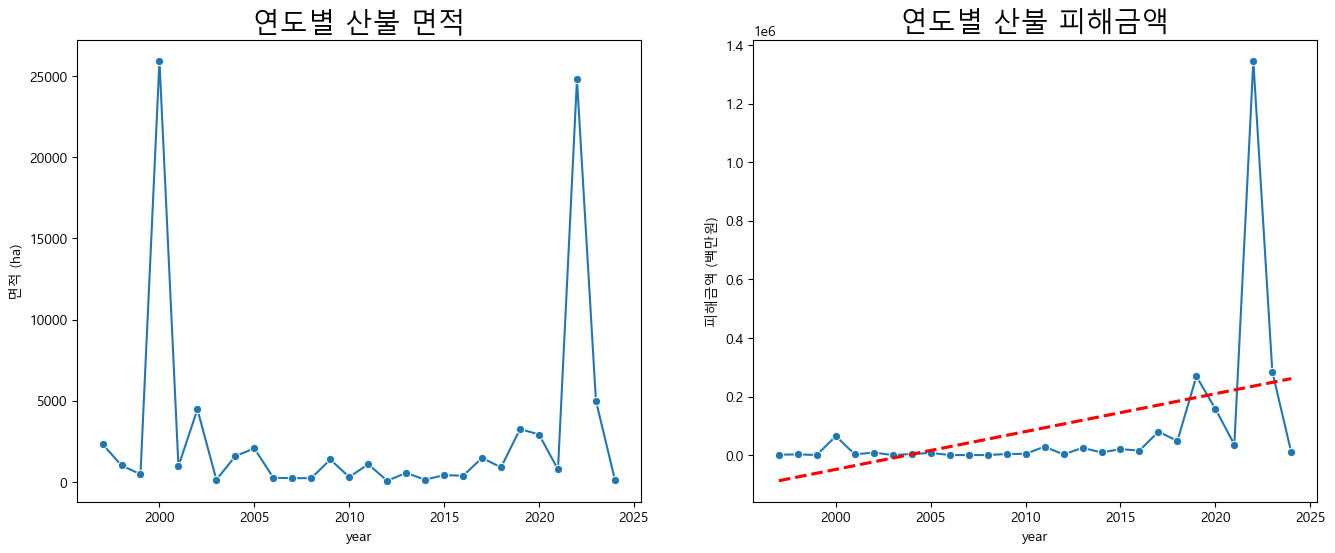

In [5]:
# 연도별 산불 면적, 피해금액 시각화
fig,ax = plt.subplots(1,2,figsize=(16,6))

sns.lineplot(data=df,x='year',y='면적 (ha)',marker='o',ax=ax[0])
ax[0].set_title('연도별 산불 면적',size=20)
sns.lineplot(data=df,x='year',y='피해금액 (백만원)',marker='o',ax=ax[1])
# 회귀선 추가
sns.regplot(data=df,x='year',y='피해금액 (백만원)',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax=ax[1])
ax[1].set_title('연도별 산불 피해금액',size=20)

plt.show()

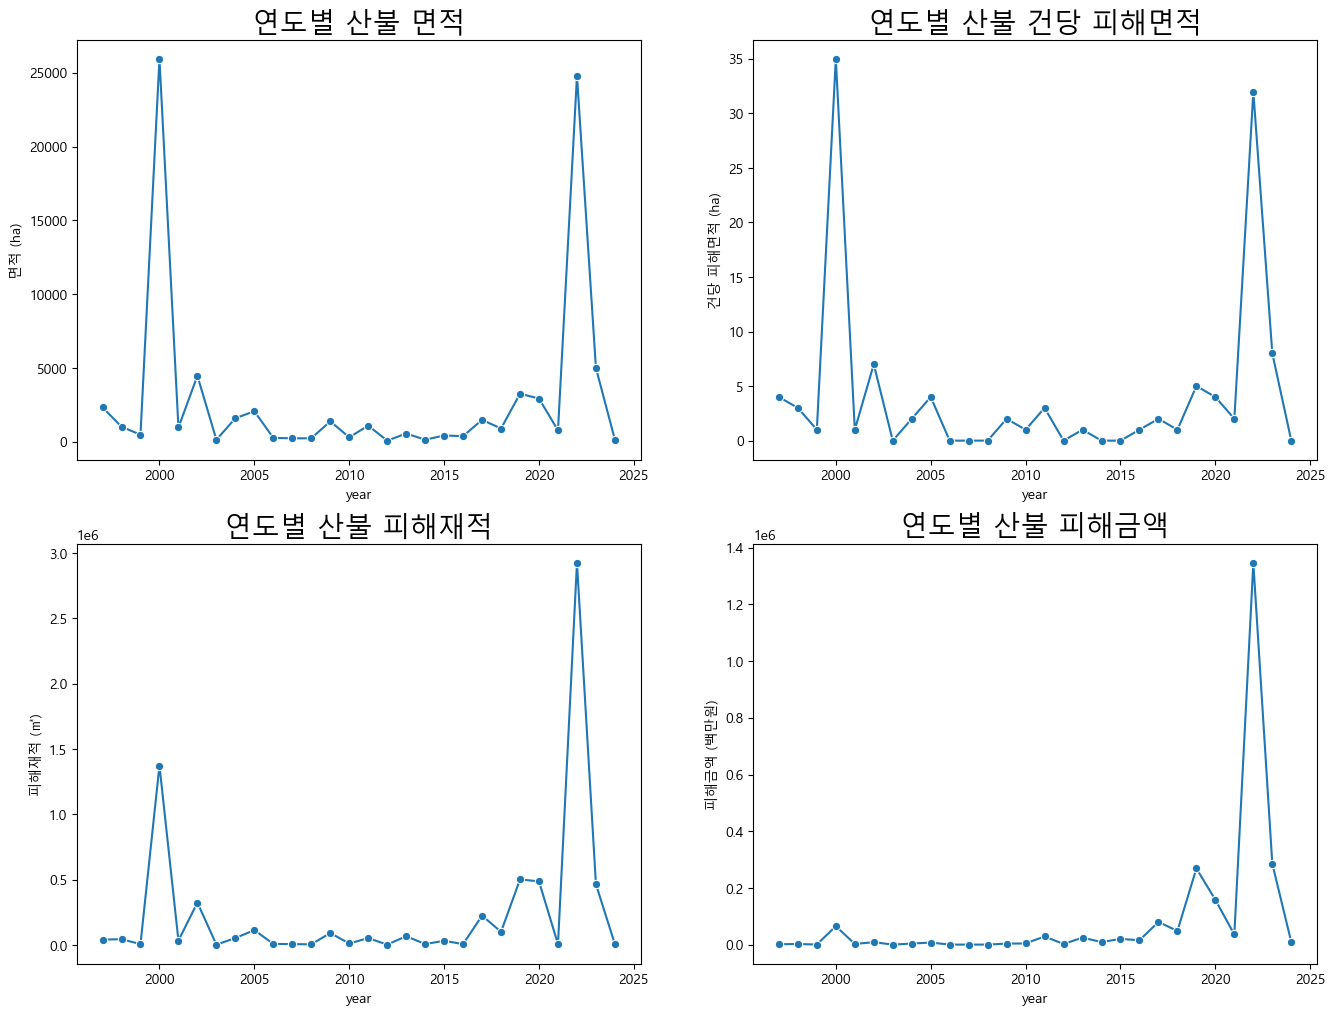

In [6]:
# 연도별 산불 면적, 건당,피해재적, 피해금액 시각화
fig,ax = plt.subplots(2,2,figsize=(16,12))

sns.lineplot(data=df,x='year',y='면적 (ha)',marker='o',ax=ax[0,0])
ax[0,0].set_title('연도별 산불 면적',size=20)
sns.lineplot(data=df,x='year',y='건당 피해면적 (ha)',marker='o',ax=ax[0,1])
ax[0,1].set_title('연도별 산불 건당 피해면적',size=20)
sns.lineplot(data=df,x='year',y='피해재적 (㎥)',marker='o',ax=ax[1,0])
ax[1,0].set_title('연도별 산불 피해재적',size=20)
sns.lineplot(data=df,x='year',y='피해금액 (백만원)',marker='o',ax=ax[1,1])
ax[1,1].set_title('연도별 산불 피해금액',size=20)

plt.show()

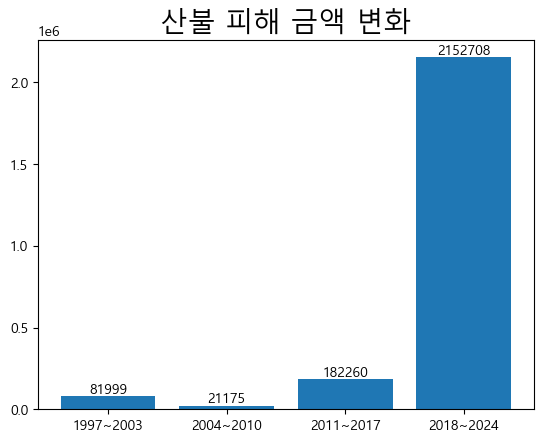

In [7]:
# 산불 피해금액 그래프를 7년 단위로 막대그래프 생성
df2 = df.query('1997<=year<=2003')
df3 = df.query('2004<=year<=2010')
df4 = df.query('2011<=year<=2017')
df5 = df.query('2018<=year<=2024')
bars = plt.bar(['1997~2003','2004~2010','2011~2017','2018~2024'],[df2['피해금액 (백만원)'].sum(),df3['피해금액 (백만원)'].sum(),df4['피해금액 (백만원)'].sum(),df5['피해금액 (백만원)'].sum()])
# 막대그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom')
plt.title('산불 피해 금액 변화',size=20)
plt.show()

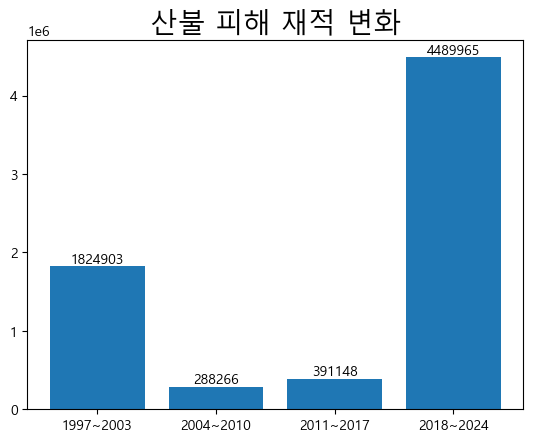

In [8]:
# 산불 피해 재적을 7년 단위로 막대그래프로 표시
bars = plt.bar(['1997~2003','2004~2010','2011~2017','2018~2024'],[df2['피해재적 (㎥)'].sum(),df3['피해재적 (㎥)'].sum(),df4['피해재적 (㎥)'].sum(),df5['피해재적 (㎥)'].sum()])
# 막대그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom')
plt.title('산불 피해 재적 변화',size=20)
plt.show()

## 월별 산불 피해 건수와 월별로 종합된 기후(기온,강수량,풍속,습도) 데이터 전처리 후 병합 후 비교
- 전처리 된 데이터들을 병합
- heatmap
- 산점도, 선 그래프 비교

In [9]:

df_fire = df_fire.replace('-',0) # -으로 처리된 부분을 0으로 바꾸기
df_fire.drop(['기간별'],axis=1,inplace=True) # 기간별 필요없는 열 날리기
df_fire.dropna(subset=['월별'],inplace=True) # 월별의 NaN 결측치 값 날리기 
df_fire

C:\Users\KDS12\AppData\Local\Temp\ipykernel_42752\591902222.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_fire = df_fire.replace('-',0) # -으로 처리된 부분을 0으로 바꾸기


,월별,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,합계,524,265,315,729,785,599,271,544,516,...,623,391,692,496,653,620,349,756,596,279
2,1월,33,15,22,10,14,20,9,32,58,...,16,36,21,29,106,29,44,88,38,18
4,2월,92,39,44,124,26,116,16,128,37,...,40,62,56,130,61,42,82,143,114,11
6,3월,104,151,74,229,227,199,55,120,124,...,252,116,192,83,141,171,44,82,229,74
8,4월,178,15,88,225,319,181,134,147,170,...,49,86,122,88,152,184,94,180,108,67
10,5월,28,5,35,49,79,11,12,9,37,...,76,21,104,3,99,26,20,115,33,17
12,6월,7,1,5,16,28,27,3,37,6,...,88,28,86,45,15,38,3,26,11,28
14,7월,0,0,0,1,0,1,0,3,0,...,4,1,3,15,15,0,7,3,0,0
16,8월,0,0,0,0,0,1,0,2,1,...,8,14,0,46,4,1,6,0,1,7
18,9월,7,5,0,0,27,1,0,3,2,...,33,5,4,3,2,2,1,11,2,6


In [10]:
# 연도, 월별, 산불 건수를 모아서 'date'에 대해 산불건수로 바꿈
# datetime으로 변환
df_fire2 = df_fire.melt(id_vars=['월별'],var_name = 'year',value_name='fire')
df_fire2 = df_fire2[['year','월별','fire']]
df_fire2['월별'] = df_fire2['월별'].str.replace('월','')
df_fire2 = df_fire2[df_fire2['월별'] !='합계']
df_fire2['date'] = pd.to_datetime(df_fire2['year'].astype(str)+'-'+df_fire2['월별'].astype(str))# datetime으로 변환
df_fire2.drop(['year','월별'],axis=1,inplace=True)
df_fire2 = df_fire2[['date','fire']]
df_fire2

,date,fire
1,1997-01-01,33
2,1997-02-01,92
3,1997-03-01,104
4,1997-04-01,178
5,1997-05-01,28
...,...,...
359,2024-08-01,7
360,2024-09-01,6
361,2024-10-01,2
362,2024-11-01,18


#### 각각의 기후 데이터에서 원하는 데이터만 뽑고 datetime으로 변환후 date_fire2에 merge

In [11]:
#원하는 데이터만 추출
df_temp = df_temp[['일시','평균기온(℃)','최고기온(℃)','최저기온(℃)']]
df_rain = df_rain[['일시','평균월강수량(mm)','최다월강수량(mm)']]
df_wind = df_wind[['일시','평균풍속(m/s)','최대풍속(m/s)']]
df_hum = df_hum[['일시','평균습도(%rh)','최저습도(%rh)']]

# 'date'로 이름 변환
df_temp.rename(columns={'일시':'date'},inplace=True)
df_rain.rename(columns={'일시':'date'},inplace=True)
df_wind.rename(columns={'일시':'date'},inplace=True)
df_hum.rename(columns={'일시':'date'},inplace=True)

# datetime으로 변환
df_temp['date'] = pd.to_datetime(df_temp['date'])
df_rain['date'] = pd.to_datetime(df_rain['date'])
df_wind['date'] = pd.to_datetime(df_wind['date'])
df_hum['date'] = pd.to_datetime(df_hum['date'])

# 'date'를 기준으로 데이터 병합
df_fire2 = pd.merge(df_fire2,df_temp,how='inner',on='date')
df_fire2 = pd.merge(df_fire2,df_rain,how='inner',on='date')
df_fire2 = pd.merge(df_fire2,df_wind,how='inner',on='date')
df_fire2 = pd.merge(df_fire2,df_hum,how='inner',on='date')
df_fire2

C:\Users\KDS12\AppData\Local\Temp\ipykernel_42752\77249043.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_wind['date'] = pd.to_datetime(df_wind['date'])


,date,fire,평균기온(℃),최고기온(℃),최저기온(℃),평균월강수량(mm),최다월강수량(mm),평균풍속(m/s),최대풍속(m/s),평균습도(%rh),최저습도(%rh)
0,1997-01-01,33,-1.9,18.0,-22.9,16.2,79.8,2.3,31.7,61,7
1,1997-02-01,92,1.0,22.7,-17.6,30.6,81.8,2.2,24.5,59,3
2,1997-03-01,104,6.5,23.2,-14.0,43.2,150.4,2.2,22.3,60,5
3,1997-04-01,178,12.1,29.8,-4.4,69.0,165.4,2.1,18.7,59,4
4,1997-05-01,28,16.9,33.1,-1.7,199.0,431.5,2.2,20.8,68,8
...,...,...,...,...,...,...,...,...,...,...,...
331,2024-08-01,7,27.9,39.3,14.6,87.3,232.9,1.5,14.9,78,16
332,2024-09-01,6,24.7,37.7,5.9,241.0,541.0,1.5,17.1,80,25
333,2024-10-01,2,16.1,31.3,-1.2,115.8,238.8,1.4,21.4,79,19
334,2024-11-01,18,9.7,25.5,-11.0,59.6,161.5,1.6,28.2,72,1


#### 기후와 산불 건수와 상관관계 분석

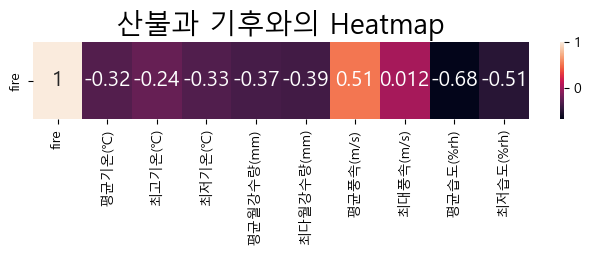

In [12]:
# 산불과 기후와의 상관관계 Heatmap

df_fire3 = df_fire2.drop(columns=['date'])
corr = df_fire3.corr().head(1)
plt.figure(figsize=(8,1))
sns.heatmap(corr,annot=True,annot_kws={"size": 15})
plt.title('산불과 기후와의 Heatmap',size=20)
plt.show()


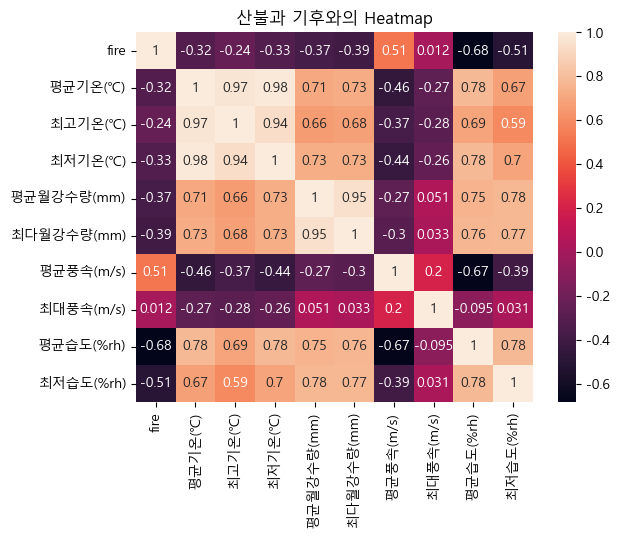

In [13]:
# 산불과 기후와의 상관관계 Heatmap
df_fire3 = df_fire2.drop(columns=['date'])
corr = df_fire3.corr()
sns.heatmap(corr,annot=True)
plt.title('산불과 기후와의 Heatmap')
plt.show()

### 다음 기온,강수량, 풍속, 습도와 산불 건수에 대한 산점도 그래프

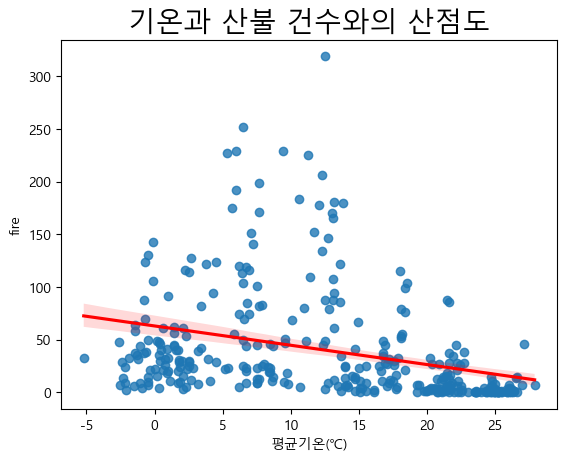

In [14]:
sns.regplot(data=df_fire2,x='평균기온(℃)',y='fire',line_kws={"color": "red"})
plt.title('기온과 산불 건수와의 산점도',size=20)
plt.show()

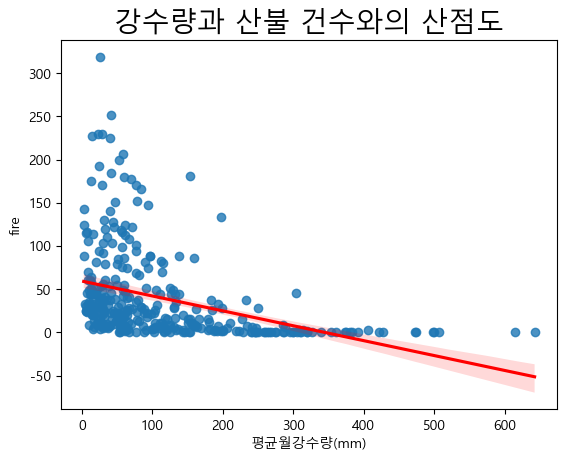

In [15]:
sns.regplot(data=df_fire2,x='평균월강수량(mm)',y='fire',line_kws={"color": "red"})
plt.title('강수량과 산불 건수와의 산점도',size=20)
plt.show()

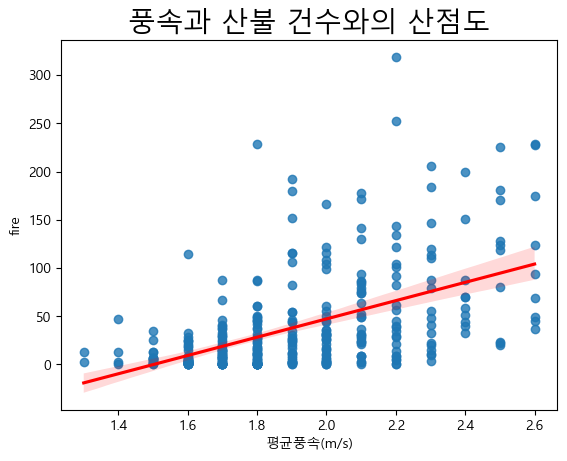

In [16]:
sns.regplot(data=df_fire2,x='평균풍속(m/s)',y='fire',line_kws={"color": "red"})
plt.title('풍속과 산불 건수와의 산점도',size=20)
plt.show()

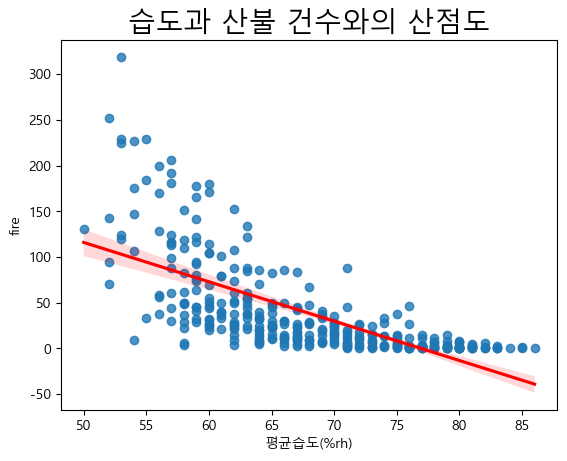

In [17]:
sns.regplot(data=df_fire2,x='평균습도(%rh)',y='fire',line_kws={"color": "red"})
plt.title('습도과 산불 건수와의 산점도',size=20)
plt.show()

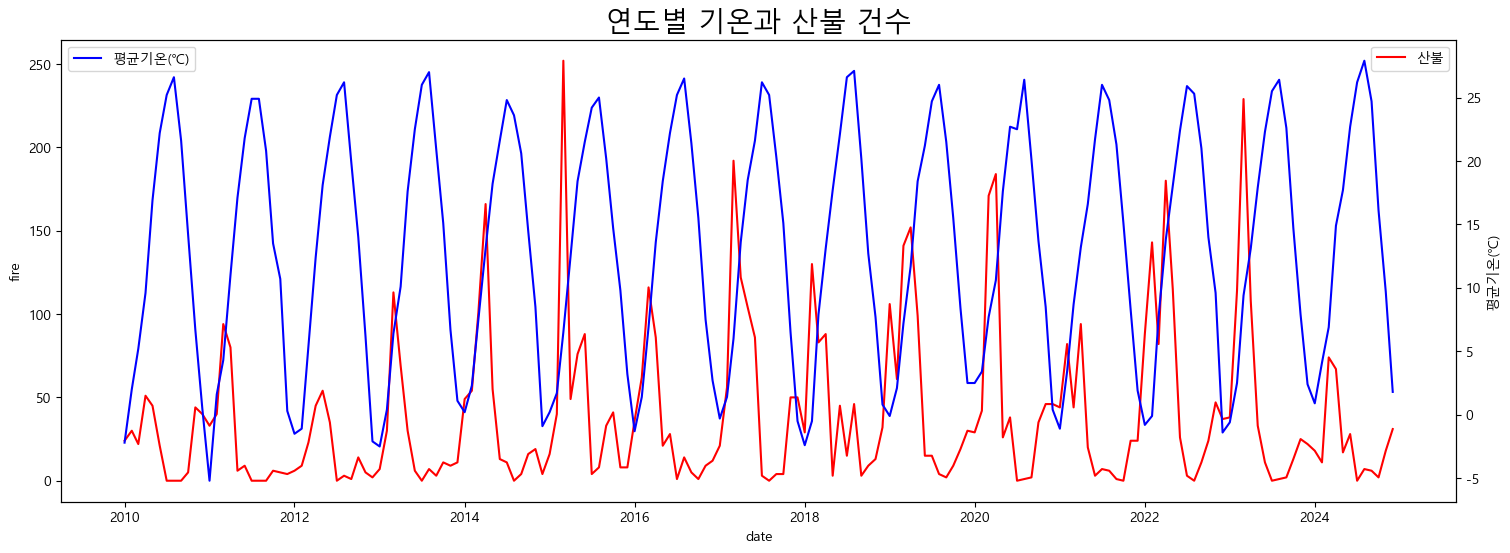

In [18]:
plt.figure(figsize=(18,6))
ax1= sns.lineplot(data=df_fire2[df_fire2['date'].dt.year>2009],x='date',y='fire',label='산불',color='red')
ax2 = ax1.twinx()
sns.lineplot(data=df_fire2[df_fire2['date'].dt.year>2009],x='date',y='평균기온(℃)',label='평균기온(℃)',color='blue',ax=ax2)
plt.title('연도별 기온과 산불 건수',size=20)
plt.legend()
plt.show()

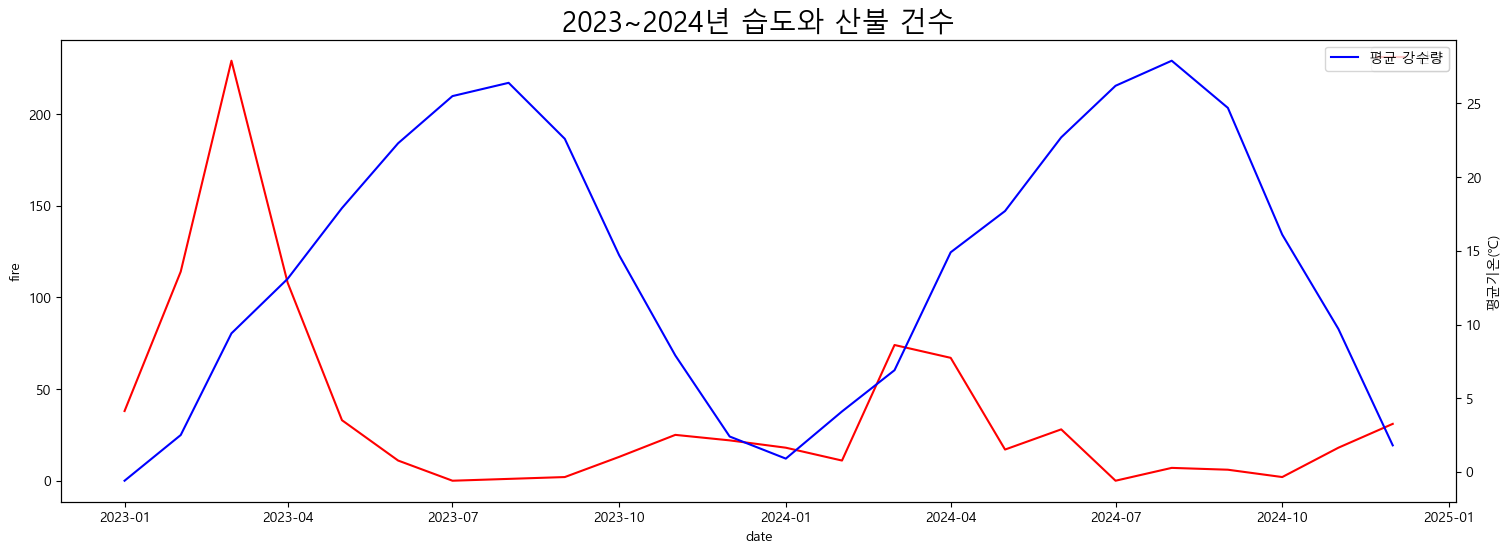

In [19]:
plt.figure(figsize=(18,6))
ax1= sns.lineplot(data=df_fire2[df_fire2['date'].dt.year>2022],x='date',y='fire',label='산불',color='red')
ax2 = ax1.twinx()
sns.lineplot(data=df_fire2[df_fire2['date'].dt.year>2022],x='date',y='평균기온(℃)',label='평균 강수량',color='blue',ax=ax2)
plt.title('2023~2024년 습도와 산불 건수',size=20)
plt.legend()
plt.show()

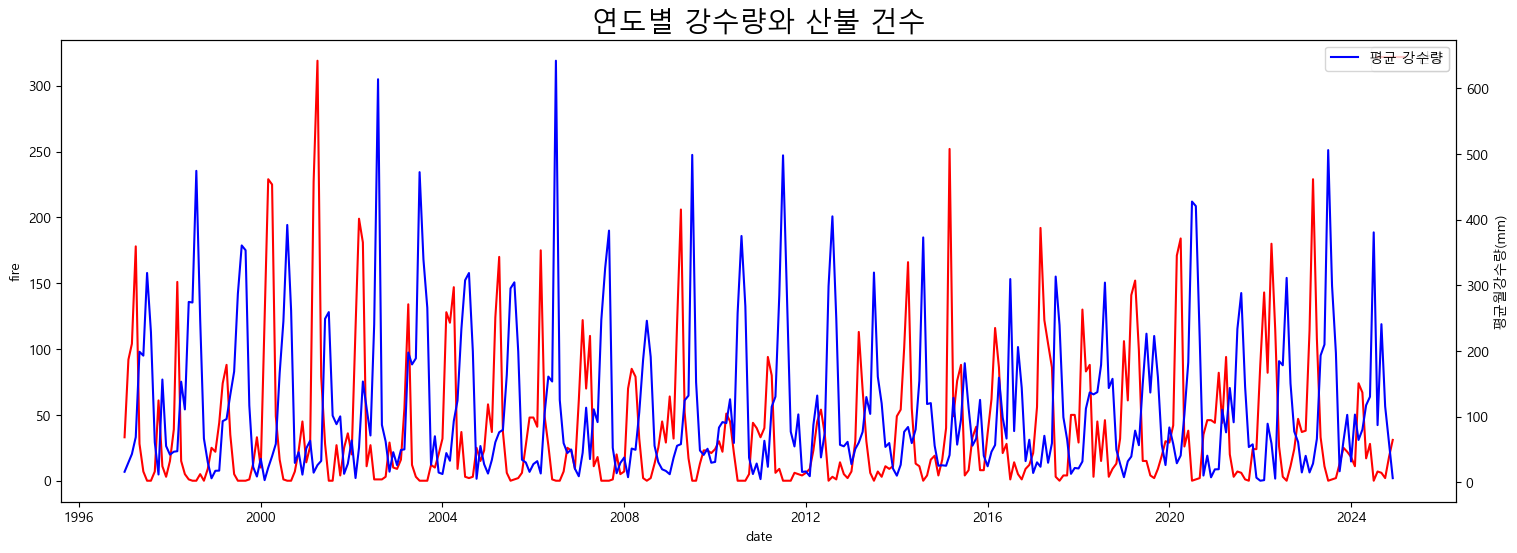

In [20]:
plt.figure(figsize=(18,6))
ax1= sns.lineplot(data=df_fire2,x='date',y='fire',label='산불',color='red')
ax2 = ax1.twinx()
sns.lineplot(data=df_fire2,x='date',y='평균월강수량(mm)',label='평균 강수량',color='blue',ax=ax2)
plt.title('연도별 강수량와 산불 건수',size=20)
plt.legend()
plt.show()

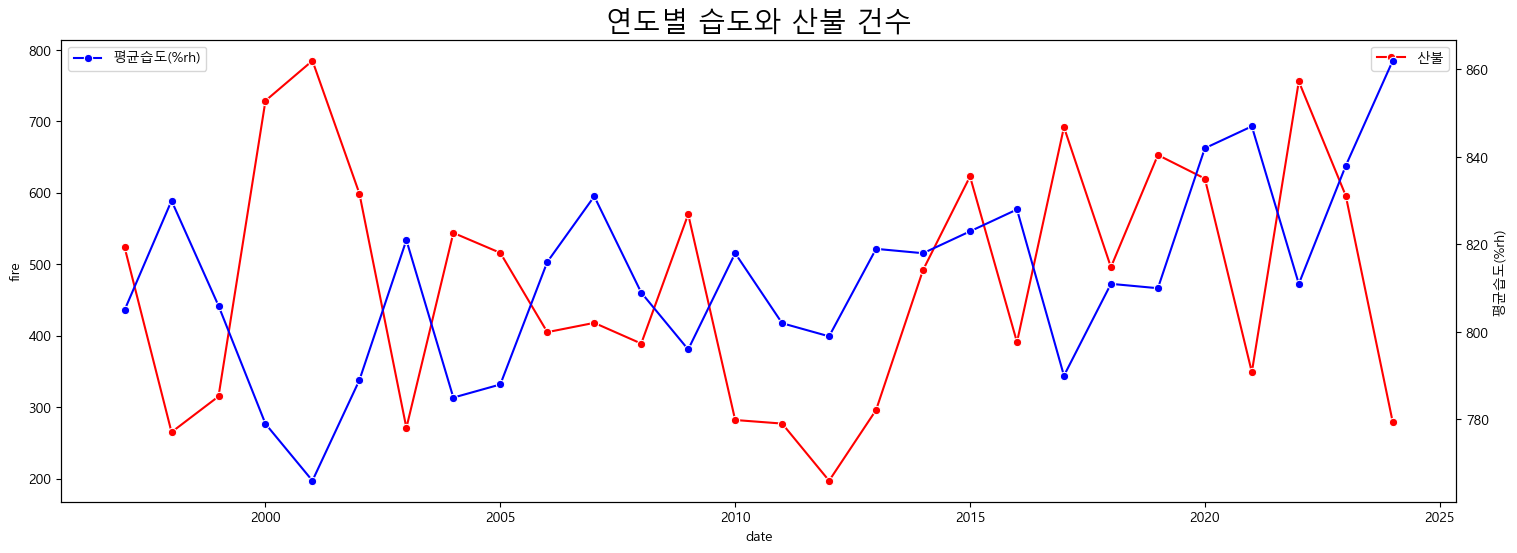

In [21]:
plt.figure(figsize=(18,6))
ax1= sns.lineplot(data=df_fire2.groupby(df_fire2['date'].dt.year).sum(numeric_only=True),x='date',y='fire',label='산불',marker='o',color='red')
ax2 = ax1.twinx()
sns.lineplot(data=df_fire2.groupby(df_fire2['date'].dt.year).sum(numeric_only=True),x='date',y='평균습도(%rh)',label='평균습도(%rh)',marker='o',color='blue',ax=ax2)
plt.title('연도별 습도와 산불 건수',size=20)
plt.legend()
plt.show()

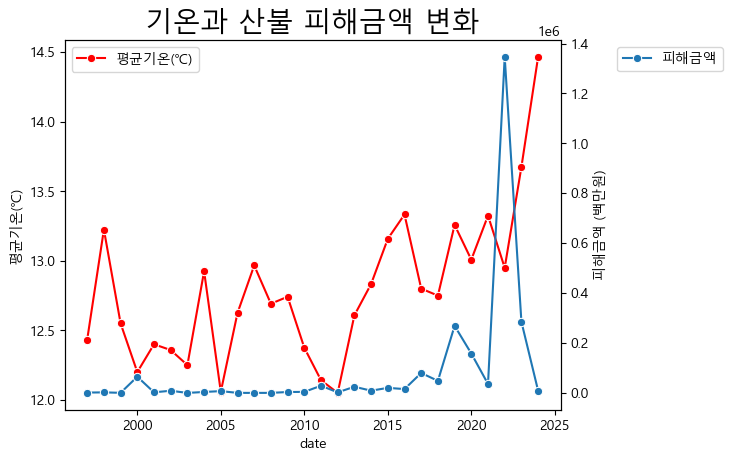

In [22]:
# 기온과 산불 피해 금액 변화
ax1 = sns.lineplot(data=df_fire2.groupby(df_fire2['date'].dt.year).mean(numeric_only=True),x='date',y='평균기온(℃)',marker='o',label='평균기온(℃)',color='red')
ax2=ax1.twinx()
sns.lineplot(data=df,x='year',y='피해금액 (백만원)',label='피해금액',marker='o',ax=ax2)
plt.title('기온과 산불 피해금액 변화',size=20)
plt.legend(bbox_to_anchor=(1.1, 1))
plt.show()

### 여름과 가을은 산불 건수가 낮고 봄, 겨울만 기후에 대해 분석한 자료

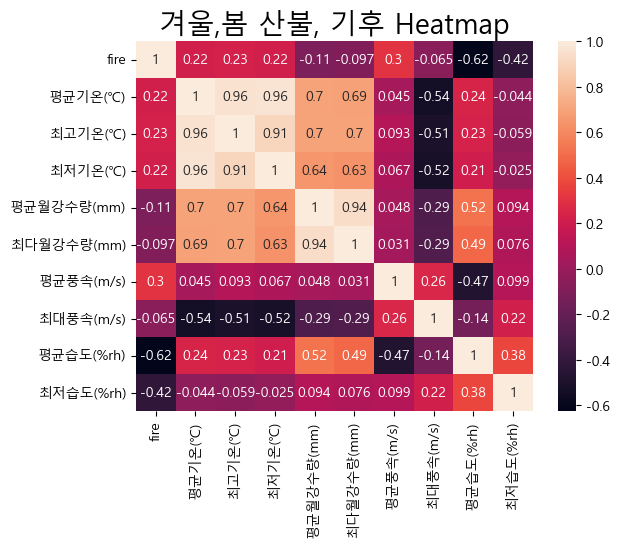

In [23]:
df_fire5 = df_fire2[df_fire2['date'].dt.month.isin([1,2,3,4,5,12])]
df_fire6 = df_fire5.drop(columns=['date'])
sns.heatmap(df_fire6.corr(),annot=True)
plt.title('겨울,봄 산불, 기후 Heatmap',size=20)
plt.show()

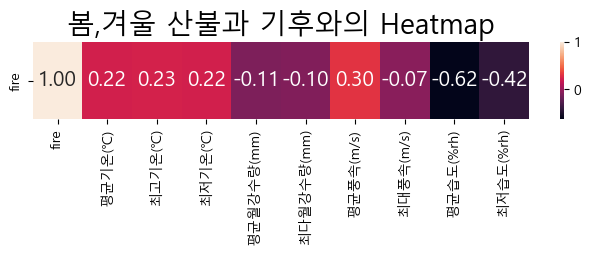

In [24]:
corr = df_fire6.corr().head(1)
plt.figure(figsize=(8,1))
sns.heatmap(corr,annot=True,fmt='.2f',annot_kws={"size": 15})
plt.title('봄,겨울 산불과 기후와의 Heatmap',size=20)
plt.show()

#### 봄, 겨울 기후와 산불 건수에 대한 산점도 그래프

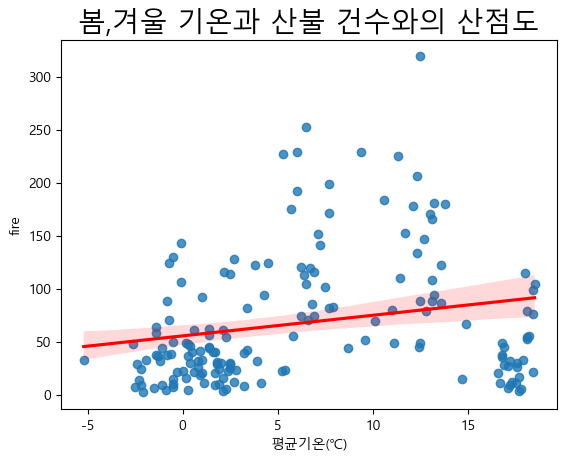

In [25]:
sns.regplot(data=df_fire5,x='평균기온(℃)',y='fire',line_kws={"color": "red"})
plt.title('봄,겨울 기온과 산불 건수와의 산점도',size=20)
plt.show()

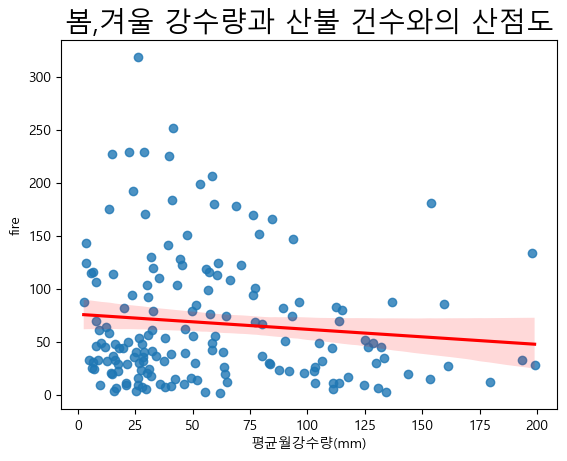

In [26]:
sns.regplot(data=df_fire5,x='평균월강수량(mm)',y='fire',line_kws={"color": "red"})
plt.title('봄,겨울 강수량과 산불 건수와의 산점도',size=20)
plt.show()

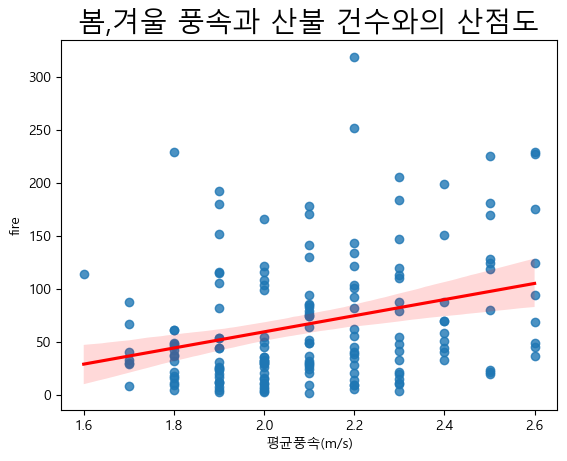

In [27]:
sns.regplot(data=df_fire5,x='평균풍속(m/s)',y='fire',line_kws={"color": "red"})
plt.title('봄,겨울 풍속과 산불 건수와의 산점도',size=20)
plt.show()

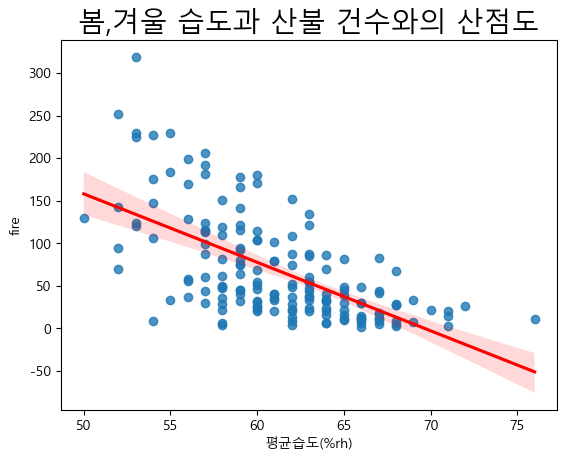

In [28]:
sns.regplot(data=df_fire5,x='평균습도(%rh)',y='fire',line_kws={"color": "red"})
plt.title('봄,겨울 습도과 산불 건수와의 산점도',size=20)
plt.show()

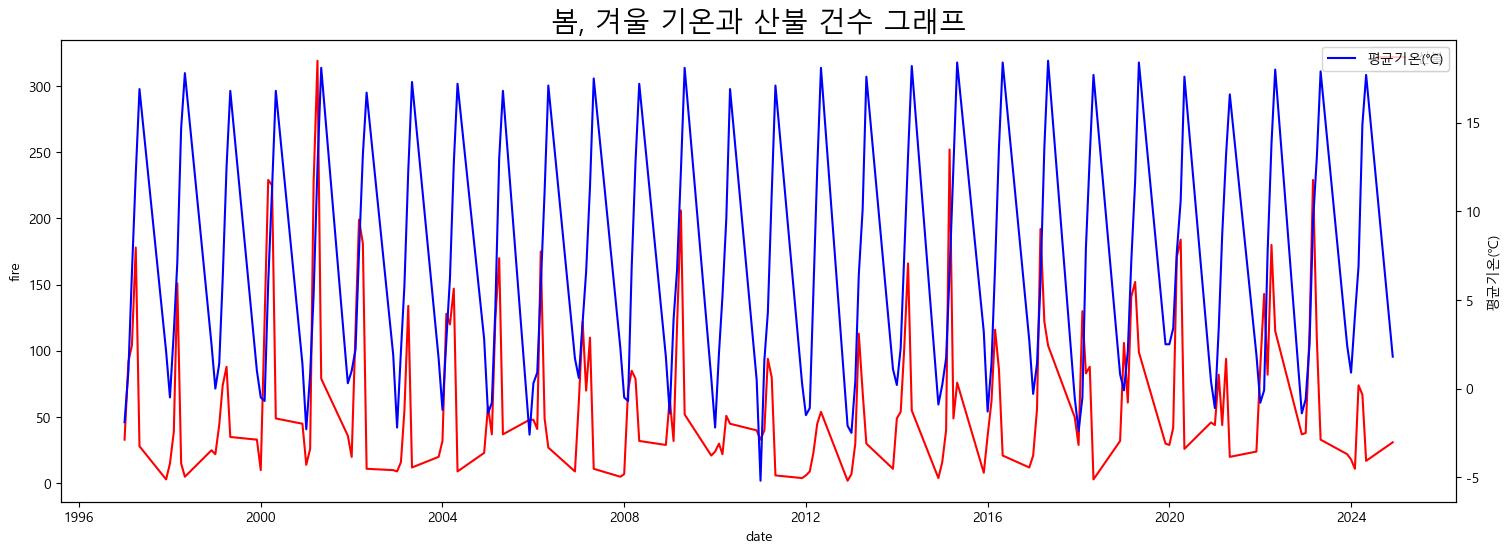

In [29]:
plt.figure(figsize=(18,6))
ax1= sns.lineplot(data=df_fire5,x='date',y='fire',label='산불',color='red')
ax2 = ax1.twinx()
sns.lineplot(data=df_fire5,x='date',y='평균기온(℃)',label='평균기온(℃)',color='blue',ax=ax2)
plt.title('봄, 겨울 기온과 산불 건수 그래프',size=20)
plt.legend()
plt.show()

### 월별, 계절별 산불 건수 종합 그래프 시각화

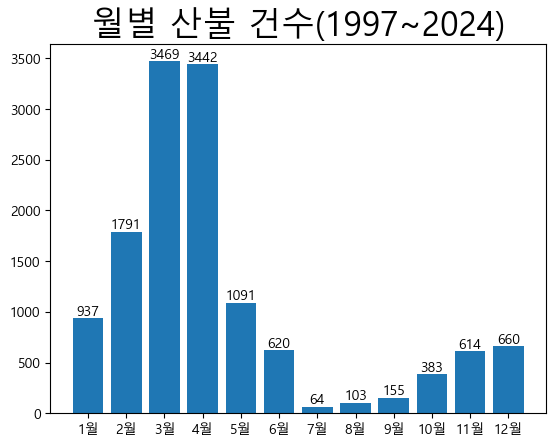

In [30]:
# 월별 산불 건수 종합 그래프 시각화
xlabel_list = []
fire_list = []
for i in range(1,13):
    xlabel_list.append(f'{i}월')
    fire_list.append(df_fire2[df_fire2['date'].dt.month==i]['fire'].sum())
bars = plt.bar(xlabel_list,fire_list)

# 막대그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom')
plt.title('월별 산불 건수(1997~2024)',size=24)
plt.show()

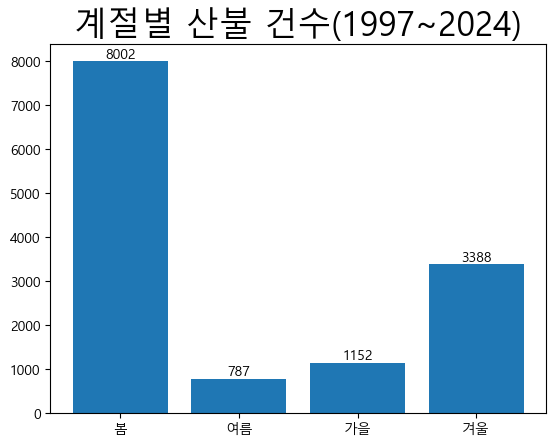

In [31]:
# 계절별 산불 건수 종합 그래프 시각화
xlabel_list2 = ['봄','여름','가을','겨울']
fire_list2 = [df_fire2[df_fire2['date'].dt.month.isin([3,4,5])]['fire'].sum(),
             df_fire2[df_fire2['date'].dt.month.isin([6,7,8])]['fire'].sum(),
             df_fire2[df_fire2['date'].dt.month.isin([9,10,11])]['fire'].sum(),
             df_fire2[df_fire2['date'].dt.month.isin([1,2,12])]['fire'].sum()]
bars = plt.bar(xlabel_list2,fire_list2)

# 막대그래프 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}',
             ha='center', va='bottom')
plt.title('계절별 산불 건수(1997~2024)',size=24)
plt.show()